<h2>Importing necessary libraries</h2>

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV,train_test_split
import matplotlib.pyplot as plt
%matplotlib inline

<h2>1. Data Collection</h2>

In [2]:
#Reading csv's 

df = pd.read_csv("StudentPerformanceFactors.csv")
assign = pd.read_csv("student_data_assign.csv")

In [3]:
# Check shapes before concat
print(f"df shape     : {df.shape}")
print(f"assign shape : {assign.shape}")

assert df.shape[0] == assign.shape[0], (
    f"Row mismatch: df has {df.shape[0]} rows, assign has {assign.shape[0]} rows"
)

# Reset both indexes to guarantee alignment
df    = df.reset_index(drop=True)
assign = assign.reset_index(drop=True)

df1 = pd.concat([df, assign], axis=1)

# Verify no NaNs were introduced by the concat
new_nulls = df1.isnull().sum()
introduced = new_nulls[new_nulls > 0]
if introduced.empty:
    print("Concat clean — no NaNs introduced")
else:
    print("WARNING: NaNs introduced after concat:")
    print(introduced)

df shape     : (6607, 6)
assign shape : (6607, 1)
Parental_Education_Level    90
dtype: int64


In [4]:
df1.head()

,Hours_Studied,Attendance(%),Previous_Scores,Parental_Education_Level,Gender,Exam_Score,Assignment_Score
0,23,84,73,High School,Male,67,81
1,19,64,59,College,Female,61,44
2,24,98,91,Postgraduate,Male,74,90
3,29,89,98,High School,Male,71,50
4,19,92,65,College,Female,70,53


<h2>2. Data Cleaning</h2>

In [5]:
df1.shape

(6607, 7)

In [6]:
df1.describe()

,Hours_Studied,Attendance(%),Previous_Scores,Exam_Score,Assignment_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,75.070531,67.235659,64.589526
std,5.990594,11.547475,14.399784,3.890456,20.175865
min,1.000000,60.000000,50.000000,55.000000,30.000000
25%,16.000000,70.000000,63.000000,65.000000,47.000000
50%,20.000000,80.000000,75.000000,67.000000,65.000000
75%,24.000000,90.000000,88.000000,69.000000,82.000000
max,44.000000,100.000000,100.000000,101.000000,99.000000


In [7]:
#checking for null values
df1.isnull().sum()

Hours_Studied                0
Attendance(%)                0
Previous_Scores              0
Parental_Education_Level    90
Gender                       0
Exam_Score                   0
Assignment_Score             0
dtype: int64

In [8]:
#Filling null values
df1['Parental_Education_Level'] = df1['Parental_Education_Level'].fillna('unknown')

In [9]:
df1.isnull().sum()

Hours_Studied               0
Attendance(%)               0
Previous_Scores             0
Parental_Education_Level    0
Gender                      0
Exam_Score                  0
Assignment_Score            0
dtype: int64

In [10]:
#checking duplicate values
df1.duplicated().sum()

np.int64(0)

<h2>3. Exploratory Data Analysis</h2>

In [11]:
#creating find_cor function to find correlation between each feature and target variable
def find_cor(df,col1,col2):
    cor = df[col1].corr(df[col2])
    print(f"Correlation between {col1} and {col2} (target column) = {cor:.2f} ")

In [12]:
find_cor(df1,'Hours_Studied','Exam_Score')
find_cor(df1,'Assignment_Score','Exam_Score')
find_cor(df1,'Previous_Scores','Exam_Score')
find_cor(df1,'Attendance(%)','Exam_Score')

Correlation between Hours_Studied and Exam_Score (target column) = 0.45 
Correlation between Assignment_Score and Exam_Score (target column) = 0.01 
Correlation between Previous_Scores and Exam_Score (target column) = 0.18 
Correlation between Attendance(%) and Exam_Score (target column) = 0.58 


In [13]:
print(df1['Hours_Studied'].value_counts())
df1['Hours_Studied'].describe()

Hours_Studied
20    465
19    441
21    431
23    411
22    402
18    401
17    381
24    357
16    351
15    315
25    289
14    269
26    263
27    229
13    218
12    192
28    171
11    146
29    134
30    123
10     94
9      86
31     77
8      58
32     54
7      51
33     40
34     29
5      21
35     20
4      17
6      17
3      12
36     11
38      7
39      7
2       6
37      6
1       3
43      1
44      1
Name: count, dtype: int64


count    6607.000000
mean       19.975329
std         5.990594
min         1.000000
25%        16.000000
50%        20.000000
75%        24.000000
max        44.000000
Name: Hours_Studied, dtype: float64

In [14]:
#creating function scatter_graph as it is used to visualise features with target
def scatter_graph(df,col1,col2):  
    plt.scatter(df[col1],df[col2])
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.title(f"{col1} vs {col2}")
    plt.show()

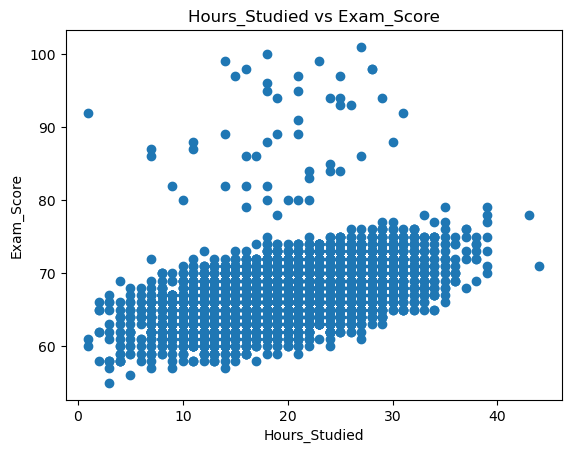

In [15]:
#Correlation between study hours and marks
scatter_graph(df1,'Hours_Studied','Exam_Score')

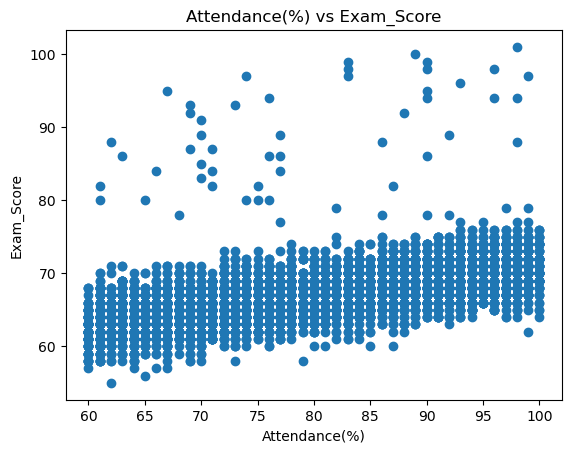

In [16]:
#Attendance vs Performance Analysis
scatter_graph(df1,'Attendance(%)','Exam_Score')

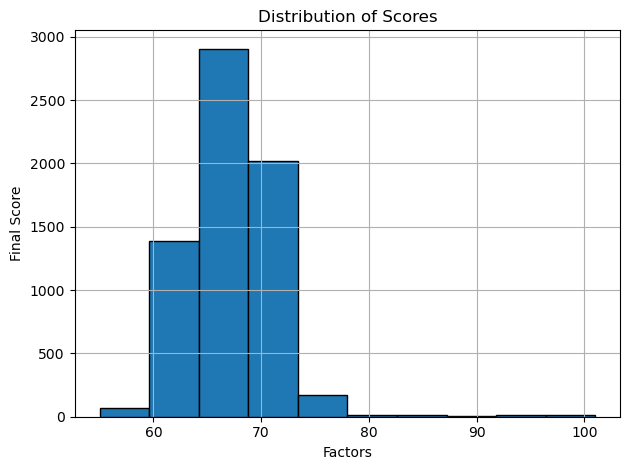

In [17]:
#Distribution of Scores
X = df1.drop('Exam_Score',axis='columns')
y = df1['Exam_Score']

plt.hist(y, bins=10, edgecolor="black")
plt.xlabel('Factors')
plt.ylabel('Final Score')
plt.title('Distribution of Scores')
plt.grid(visible=True)
plt.tight_layout()
plt.show()

<h2>4. Data Preprocessing</h2>

In [18]:
# Check correlation/impact before dropping
gender_dummies = pd.get_dummies(df1['Gender'], drop_first=True)
temp = pd.concat([gender_dummies, df1['Exam_Score']], axis=1)
print("Gender correlation with Exam_Score:")
print(temp.corr()['Exam_Score'])

# Also check mean score by gender group
print("\nMean Exam_Score by Gender:")
print(df1.groupby('Gender')['Exam_Score'].mean())

# NOW drop only if correlation is negligible
cor = df1['Gender'].map({'Male': 0, 'Female': 1}).corr(df1['Exam_Score'])
print(f"\nCorrelation: {cor:.4f}")

if abs(cor) < 0.05:  # your threshold, be explicit about it
    df1 = df1.drop('Gender', axis='columns').copy()
    print("Gender dropped: correlation below threshold (0.05)")
else:
    print("Gender retained: meaningful correlation found")

Gender correlation with Exam_Score:
Male         -0.002032
Exam_Score    1.000000
Name: Exam_Score, dtype: float64

Mean Exam_Score by Gender:
Gender
Female    67.244898
Male      67.228894
Name: Exam_Score, dtype: float64

Correlation: 0.0020
Gender dropped: correlation below threshold (0.05)


In [19]:
#creating function to remove outliers
def remove_outliers_iqr(df, column):
    Q1  = df[column].quantile(0.25)
    Q3  = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Keep only rows WITHIN bounds
    df_clean = df[(df[column] >= lower) & 
                  (df[column] <= upper)]
    
    print(f"Original rows  of {column} are: {len(df)}")
    print(f"Cleaned rows  of {column} are:   : {len(df_clean)}")
    print(f"Removed rows  of {column} are:   : {len(df) - len(df_clean)}")
    
    return df_clean

In [20]:
features_to_clean = ['Hours_Studied', 'Attendance(%)', 'Previous_Scores']
df_cleaned = df1.copy()
for col in features_to_clean:
    df_cleaned = remove_outliers_iqr(df_cleaned, col)
 
df_cleaned = df_cleaned.reset_index(drop=True)
print(f"\nRows after outlier removal: {len(df_cleaned)}  "
      f"(was {len(df1)})")

Original rows  of Hours_Studied are: 6607
Cleaned rows  of Hours_Studied are:   : 6564
Removed rows  of Hours_Studied are:   : 43
Original rows  of Attendance(%) are: 6564
Cleaned rows  of Attendance(%) are:   : 6564
Removed rows  of Attendance(%) are:   : 0
Original rows  of Previous_Scores are: 6564
Cleaned rows  of Previous_Scores are:   : 6564
Removed rows  of Previous_Scores are:   : 0

Rows after outlier removal: 6564  (was 6607)


In [21]:
#spliting data in train and test ratio
X = df_cleaned.drop('Exam_Score', axis='columns')
y = df_cleaned['Exam_Score']
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
#serialising dataset
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)
 
print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")

X_train: (5251, 5)  X_test: (1313, 5)


In [23]:
#creating pipeline for data encoding and normalising
def build_pipeline(num_att,cat_att):
    num_pipeline = Pipeline([
        ('imputer',SimpleImputer(strategy='mean')),
        ('scaler',StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer',SimpleImputer(strategy='most_frequent')),
        ('ohe',OneHotEncoder(handle_unknown='ignore'))
    ])
    
    full_pipeline = ColumnTransformer([
        ("num",num_pipeline,num_att),
        ("cat",cat_pipeline,cat_att)
    ])

    return full_pipeline

In [24]:
#calling build_pipeline function and return value is stored in preprocessor variable
num_att = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_att = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
 
print("Numeric features   :", num_att)
print("Categorical features:", cat_att)
 
preprocessor = build_pipeline(num_att, cat_att)

Numeric features   : ['Hours_Studied', 'Attendance(%)', 'Previous_Scores', 'Assignment_Score']
Categorical features: ['Parental_Education_Level']


<h2>5. Model Building, Training, Testing and Evaluation</h2>

In [25]:
#Using Linear Regression Model
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lr', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)

print(f"\nTest R2  : {r2_score(y_test, y_pred_lr):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_lr):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_lr):.4f}")


Test R2  : 0.5317
Test MAE : 1.4372
Test MSE : 7.1200


In [26]:
#Using Decision Tree Model
dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('Decision Tree',DecisionTreeRegressor(random_state=42)),
])

dt_pipeline.fit(X_train, y_train)
y_pred_dt = dt_pipeline.predict(X_test)

print(f"\nTest R2  : {r2_score(y_test, y_pred_dt):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_dt):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_dt):.4f}")


Test R2  : 0.0444
Test MAE : 2.1462
Test MSE : 14.5270


In [27]:
#Using Random Forest model with different parameters
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('rf',RandomForestRegressor(random_state=42))
])

param_grid = {
    'rf__n_estimators'     : [100, 175, 250],
    'rf__max_depth'        : [10, 20, None],
    'rf__min_samples_split': [2, 20, 50],
}
        
grid_search = GridSearchCV(
    estimator  = rf_pipeline,
    param_grid = param_grid,
    cv  = 5,
    scoring = 'r2',
    n_jobs = -1,
    verbose = 1
)
        
grid_search.fit(X_train, y_train)
        
print("Best parameters :", grid_search.best_params_)
print(f"Best CV R2      : {grid_search.best_score_:.4f}")
        
best_rf = grid_search.best_estimator_
        
y_pred_rf = best_rf.predict(X_test)          
        
print(f"\nTest R2  : {r2_score(y_test, y_pred_rf):.4f}")
print(f"Test MAE : {mean_absolute_error(y_test, y_pred_rf):.4f}")
print(f"Test MSE : {mean_squared_error(y_test, y_pred_rf):.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters : {'rf__max_depth': 20, 'rf__min_samples_split': 50, 'rf__n_estimators': 175}
Best CV R2      : 0.5712

Test R2  : 0.5098
Test MAE : 1.5077
Test MSE : 7.4518


In [28]:
# Show the chosen model
results = {
    'Linear Regression' : r2_score(y_test, y_pred_lr),
    'Decision Tree'     : r2_score(y_test, y_pred_dt),
    'Random Forest'     : r2_score(y_test, y_pred_rf),
}

best_model_name = max(results, key=results.get)

print("Model Comparison (R² Score):")
for name, score in results.items():
    marker = " ✅ <-- chosen" if name == best_model_name else ""
    print(f"  {name:<22}: {score:.4f}{marker}")

print(f"\n✅ Best model selected: {best_model_name}")

Model Comparison (R² Score):
  Linear Regression     : 0.5317 ✅ <-- chosen
  Decision Tree         : 0.0444
  Random Forest         : 0.5098

✅ Best model selected: Linear Regression


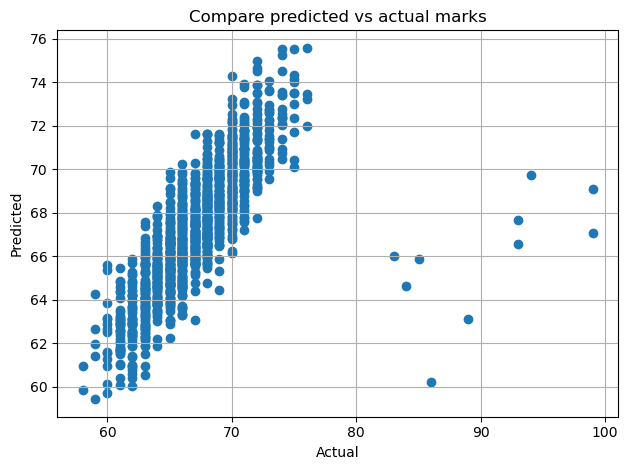

In [29]:
#visualising actual vs predicted values
plt.scatter(y_test,y_pred_rf)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Compare predicted vs actual marks')
plt.grid(visible=True)
plt.tight_layout()
plt.show()

<h2>6. Saving Model</h2>

In [30]:
import joblib

model_objects = {
    'Linear Regression' : lr_pipeline,
    'Decision Tree'     : dt_pipeline,
    'Random Forest'     : best_rf,
}

best_model = model_objects[best_model_name]
filename   = f"best_model_{best_model_name.lower().replace(' ', '_')}.pkl"
joblib.dump(best_model, filename)
print(f"Saved: {filename}")

Saved: best_model_linear_regression.pkl
